In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

**Задание 1.** Белок состоит из N=100 аминокислотных остатков. Каждый
остаток может находиться в 10 различных конформациях
(например, различные значения двугранных углов). Время
«попытки» перейти из одной конформации в другую
(элементарный шаг) примем равным характерному времени
молекулярных колебаний τ=10−13 с.

Требуется:

- Вычислить полное число возможных конформаций Ω

- Найти время полного перебора всех конформаций T=τ⋅Ω

- Сравнить полученное время с возрастом Вселенной

Общее число конформаций:

омега = 10^N = 10^100

Время полного перебора:

T = тау*омега = 10^(-13)*10^100 = 10^87 c

Сравнение с возрастом Вселенной:

Согласно современным научным данным, возраст Вселенной составляет примерно 13,8 миллиардов лет (13,799 +- 0,021 млрд лет). В секундах это примерно 4,35*10^17 с

Что в 10^70 раз меньше, чем время полного перебора.

**Вывод: Время перебора всех конформаций колоссально превышает возраст Вселенной, что иллюстрирует парадокс Левинталя.**

**Задание 2.** Для белков длины N = 50, 100, 200, 400 остатков.
Используя формулу для одно-доменного белка построить
график tfold(N).
Сравнить с оценкой Левинталя.
Найти, при каком N время сворачивания по обоим моделям
превышает возраст Вселенной и при каком — время жизни
эритроцита.

Формула для однодоменногог белка: tfold(N) ~ e^(beta*N^(2/3))

Примем бета = 1, тогда

tfold=t0*e^(N^(2/3))

Модель Левинталя: t_Lev = t0 * 10^N


N        t_fold (с)           t_Levinthal (с)           log10(t_fold)       
--------------------------------------------------------------------------------
50       7.84e-08             10^37                     -7.11               
100      2.27e-04             10^87                     -3.64               
200      7.12e+01             10^187                    1.85                
400      3.78e+10             10^387                    10.58               

Поиск критических N:
  Возраст Вселенной (10^17.64 с) достигается при N ≈ 600
    log10(t_fold) = 17.89
  Время жизни эритроцита (10^7.02 с) достигается при N ≈ 320
    log10(t_fold) = 7.32

Для модели Левинталя:
  Возраст Вселенной достигается при N ≈ 31 (10^31 конформаций)
  Время жизни эритроцита достигается при N ≈ 20


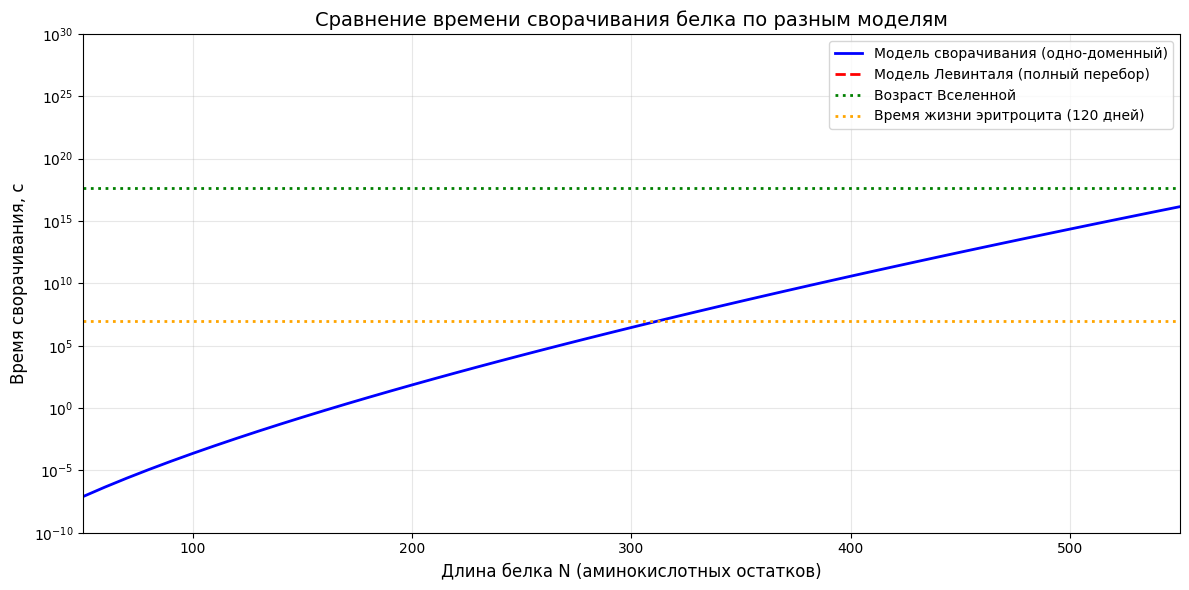

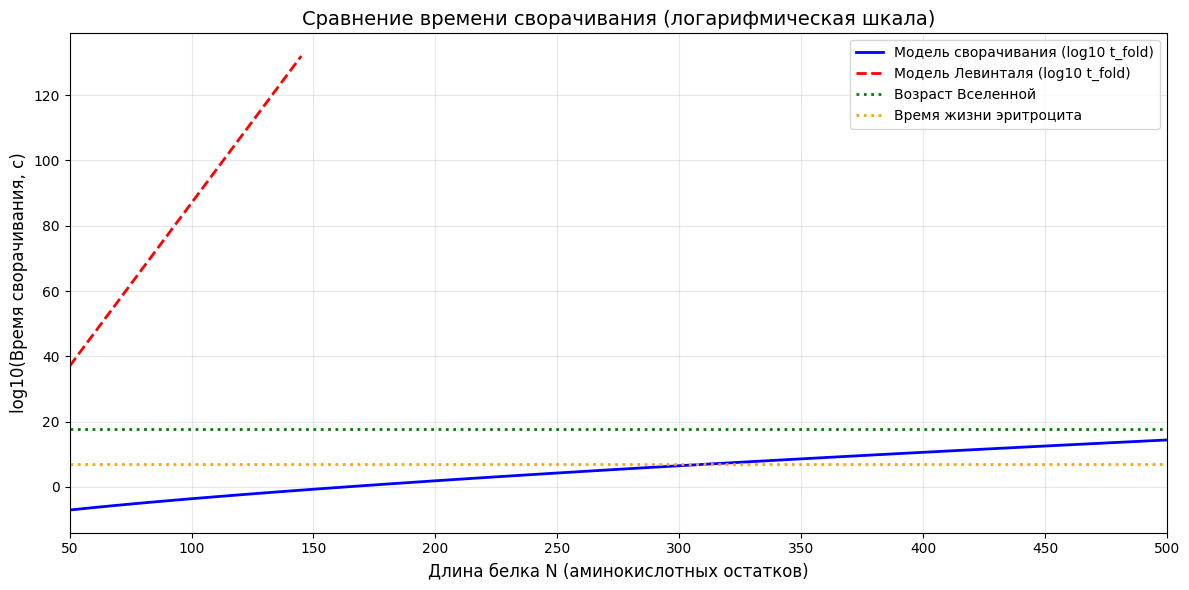

In [ ]:
def log10_t_fold(N, tau0=1e-13, alpha=1.0):
    return np.log10(tau0) + (alpha * N**(2/3)) / np.log(10)

def log10_t_levinthal(N, tau0=1e-13):
    return np.log10(tau0) + N

age_universe_sec = 13.8e9 * 365.25 * 24 * 3600
log10_age_universe = np.log10(age_universe_sec)  # ≈ 17.64

erythrocyte_lifetime_sec = 120 * 24 * 3600
log10_erythrocyte = np.log10(erythrocyte_lifetime_sec)  # ≈ 7.02

N_values = [50, 100, 200, 400]
print("\n{:<8} {:<20} {:<25} {:<20}".format("N", "t_fold (с)", "t_Levinthal (с)", "log10(t_fold)"))
print("-" * 80)

for N_val in N_values:
    log10_tf = log10_t_fold(N_val)
    t_fold = 10**log10_tf if log10_tf < 308 else float('inf')

    log10_tl = log10_t_levinthal(N_val)

    print("{:<8} {:<20} {:<25} {:<20.2f}".format(
        N_val,
        f"10^{log10_tf:.2f}" if log10_tf > 100 else f"{t_fold:.2e}",
        f"10^{log10_tl:.0f}",
        log10_tf
    ))

print("\nПоиск критических N:")

# для модели сворачивания
N_test = np.arange(50, 800, 10)
log10_t_folds = log10_t_fold(N_test)

# возраст Вселенной
idx_universe = np.where(log10_t_folds > log10_age_universe)[0]
if len(idx_universe) > 0:
    N_crit_universe = N_test[idx_universe[0]]
    print(f"  Возраст Вселенной (10^{log10_age_universe:.2f} с) достигается при N ≈ {N_crit_universe}")
    print(f"    log10(t_fold) = {log10_t_folds[idx_universe[0]]:.2f}")

# время жизни эритроцита
idx_erythrocyte = np.where(log10_t_folds > log10_erythrocyte)[0]
if len(idx_erythrocyte) > 0:
    N_crit_eryth = N_test[idx_erythrocyte[0]]
    print(f"  Время жизни эритроцита (10^{log10_erythrocyte:.2f} с) достигается при N ≈ {N_crit_eryth}")
    print(f"    log10(t_fold) = {log10_t_folds[idx_erythrocyte[0]]:.2f}")

# для модели Левинталя (критические N)
print("\nДля модели Левинталя:")
N_lev_universe = log10_age_universe - np.log10(1e-13)
print(f"  Возраст Вселенной достигается при N ≈ {N_lev_universe:.0f} (10^{N_lev_universe:.0f} конформаций)")
N_lev_eryth = log10_erythrocyte - np.log10(1e-13)
print(f"  Время жизни эритроцита достигается при N ≈ {N_lev_eryth:.0f}")

# график (в логарифмическом масштабе)
plt.figure(figsize=(12, 6))

# модель сворачивания
plt.semilogy(N_test, 10**np.clip(log10_t_folds, -100, 100), 'b-', linewidth=2, label='Модель сворачивания (одно-доменный)')

# модель Левинталя - схематично (только до N=100, дальше бесконечность)
N_lev_plot = np.arange(50, 101, 5)
log10_t_lev_plot = log10_t_levinthal(N_lev_plot)
t_lev_plot = 10**np.clip(log10_t_lev_plot, -100, 100)
plt.semilogy(N_lev_plot, t_lev_plot, 'r--', linewidth=2, label='Модель Левинталя (полный перебор)')

# горизонтальные линии
plt.axhline(y=age_universe_sec, color='g', linestyle=':', linewidth=2, label='Возраст Вселенной')
plt.axhline(y=erythrocyte_lifetime_sec, color='orange', linestyle=':', linewidth=2, label='Время жизни эритроцита (120 дней)')

plt.xlabel('Длина белка N (аминокислотных остатков)', fontsize=12)
plt.ylabel('Время сворачивания, с', fontsize=12)
plt.title('Сравнение времени сворачивания белка по разным моделям', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(50, 550)
plt.ylim(1e-10, 1e30)
plt.tight_layout()
plt.show()

# альтернативный график в логарифмических координатах для лучшего понимания
plt.figure(figsize=(12, 6))
plt.plot(N_test, log10_t_folds, 'b-', linewidth=2, label='Модель сворачивания (log10 t_fold)')

# для модели Левинталя
N_lev_full = np.arange(50, 150, 5)
log10_t_lev_full = log10_t_levinthal(N_lev_full)
plt.plot(N_lev_full, log10_t_lev_full, 'r--', linewidth=2, label='Модель Левинталя (log10 t_fold)')

plt.axhline(y=log10_age_universe, color='g', linestyle=':', linewidth=2, label='Возраст Вселенной')
plt.axhline(y=log10_erythrocyte, color='orange', linestyle=':', linewidth=2, label='Время жизни эритроцита')

plt.xlabel('Длина белка N (аминокислотных остатков)', fontsize=12)
plt.ylabel('log10(Время сворачивания, с)', fontsize=12)
plt.title('Сравнение времени сворачивания (логарифмическая шкала)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(50, 500)
plt.tight_layout()
plt.show()

Вывод:

**Поиск критических N:**

  Возраст Вселенной (10^17.64 с) достигается при N ≈ 600
    log10(t_fold) = 17.89

  Время жизни эритроцита (10^7.02 с) достигается при N ≈ 320
    log10(t_fold) = 7.32

**Для модели Левинталя:**

  Возраст Вселенной достигается при N ≈ 31 (10^31 конформаций)

  Время жизни эритроцита достигается при N ≈ 20

**Задание 3.** Закрепили два остатка на расстоянии r друг от друга. Между ними — петля из L
остатков. Энтропия петли (для гауссовой цепи):

Sloop=...

а – длина мономера.
Рассчитать потерю энтропии для L=10, r=5a (плотная глобула) и для L=10, r=20а
(вытянутая петля).

In [ ]:
def entropy_loss(L, r, a=1.0):
    term1 = -1.5 * np.log(L)
    term2 = - (3 * r**2) / (4 * L * a**2)
    return term1 + term2

L = 10
a = 1.0

r1 = 5 * a
delta_S1 = entropy_loss(L, r1, a)

r2 = 20 * a
delta_S2 = entropy_loss(L, r2, a)

print(f"Длина петли L = {L}")
print(f"Длина мономера a = {a} (условно)")
print(f"\nСлучай 1 (плотная глобула): r = {r1} = {r1/a}a")
print(f"  Потеря энтропии ΔS = {delta_S1:.4f} k_B")
print(f"\nСлучай 2 (вытянутая петля): r = {r2} = {r2/a}a")
print(f"  Потеря энтропии ΔS = {delta_S2:.4f} k_B")
print(f"\nОтношение ΔS₂/ΔS₁ = {delta_S2/delta_S1:.2f}")
print("\nВЫВОД: При сильном вытягивании петли потеря энтропии значительно больше,")
print("что делает такую конформацию менее вероятной (фактор Больцмана exp(-ΔS/k_B)).")

Длина петли L = 10
Длина мономера a = 1.0 (условно)

Случай 1 (плотная глобула): r = 5.0 = 5.0a
  Потеря энтропии ΔS = -5.3289 k_B

Случай 2 (вытянутая петля): r = 20.0 = 20.0a
  Потеря энтропии ΔS = -33.4539 k_B

Отношение ΔS₂/ΔS₁ = 6.28

ВЫВОД: При сильном вытягивании петли потеря энтропии значительно больше,
что делает такую конформацию менее вероятной (фактор Больцмана exp(-ΔS/k_B)).


**Задание 4.** По точкам зависимости наблюдаемой константы скорости от концентрации денатуранта восстановить кинетические параметры сворачивания и разворачивания


Исходные данные:
[D], M     k_obs (с⁻¹)     ln(k_obs)      
---------------------------------------------
0          50.00           3.9120         
1          30.00           3.4012         
2          15.00           2.7081         
3          6.00            1.7918         
4          2.00            0.6931         
5          1.50            0.4055         
6          4.00            1.3863         
7          15.00           2.7081         
8          40.00           3.6889         


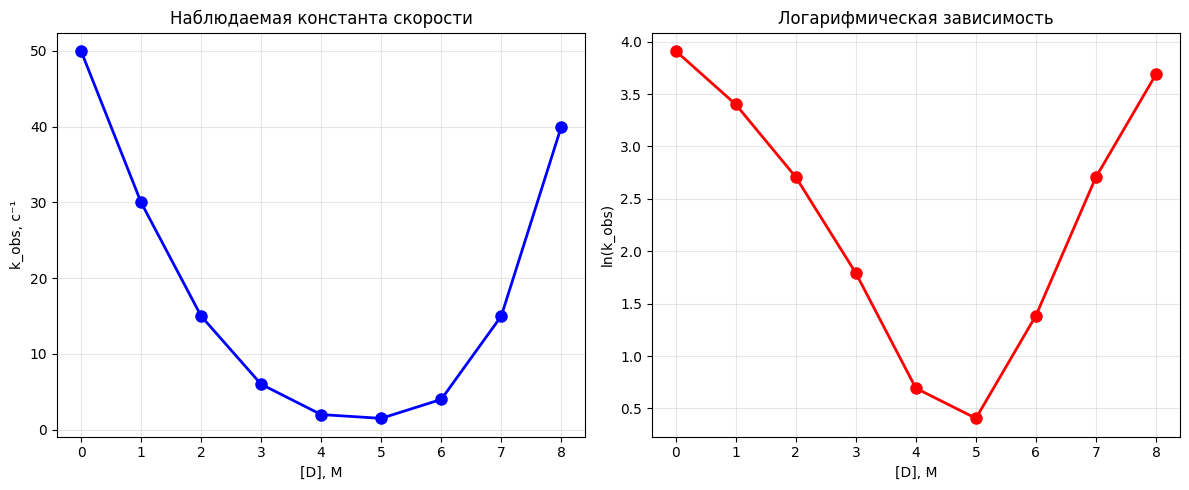


СВОРАЧИВАНИЕ (левая ветвь, [D] ≤ 5)
Точки аппроксимации: [D] = [0, 1, 2, 3, 4, 5]
Уравнение: ln(k_f) = 4.0500 - 0.7592·[D]
k_f(H₂O) = 57.40 с⁻¹
m_f = 0.7592 M⁻¹
Коэффициент детерминации R² = 0.9817

РАЗВОРАЧИВАНИЕ (правая ветвь, [D] ≥ 6) 
Точки аппроксимации: [D] = [6, 7, 8]
Уравнение: ln(k_u) = -5.4646 + 1.1513·[D]
k_u(H₂O) = 4.2339e-03 с⁻¹
m_u = 1.1513 M⁻¹
Коэффициент детерминации R² = 0.9927
Температура T = 298 K
RT = 0.6 ккал/моль
Константа равновесия K_eq = k_f/k_u = 57.40 / 4.2339e-03 = 1.36e+04
ΔG(H₂O) = -RT·ln(K_eq) = -0.6 × ln(1.36e+04) = -5.71 ккал/моль

Точка перехода (k_f = k_u): [D]₁/₂ = 4.98 M


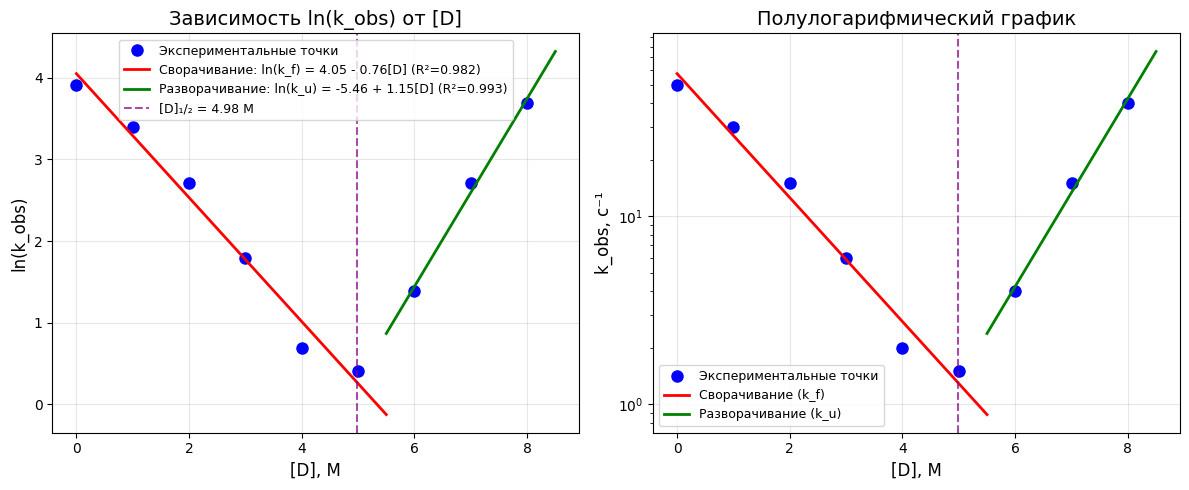

In [ ]:
D_conc = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
k_obs = np.array([50, 30, 15, 6, 2, 1.5, 4, 15, 40])
ln_k_obs = np.log(k_obs)

print("\nИсходные данные:")
print("{:<10} {:<15} {:<15}".format("[D], M", "k_obs (с⁻¹)", "ln(k_obs)"))
print("-" * 45)
for d, k, lnk in zip(D_conc, k_obs, ln_k_obs):
    print("{:<10} {:<15.2f} {:<15.4f}".format(d, k, lnk))

# график исходных данных
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(D_conc, k_obs, 'bo-', linewidth=2, markersize=8)
plt.xlabel('[D], M')
plt.ylabel('k_obs, с⁻¹')
plt.title('Наблюдаемая константа скорости')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(D_conc, ln_k_obs, 'ro-', linewidth=2, markersize=8)
plt.xlabel('[D], M')
plt.ylabel('ln(k_obs)')
plt.title('Логарифмическая зависимость')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# левая ветвь (сворачивание) - точки 0-5
mask_fold = D_conc <= 5
D_fold = D_conc[mask_fold]
ln_k_fold = ln_k_obs[mask_fold]

coeff_fold = np.polyfit(D_fold, ln_k_fold, 1)
slope_fold = coeff_fold[0]
intercept_fold = coeff_fold[1]

m_f = -slope_fold
ln_kf0 = intercept_fold
kf0 = np.exp(ln_kf0)

# R² для левой ветви
ln_k_fold_pred = np.polyval(coeff_fold, D_fold)
ss_res_fold = np.sum((ln_k_fold - ln_k_fold_pred)**2)
ss_tot_fold = np.sum((ln_k_fold - np.mean(ln_k_fold))**2)
r2_fold = 1 - (ss_res_fold / ss_tot_fold)

print(f"\nСВОРАЧИВАНИЕ (левая ветвь, [D] ≤ 5)")
print(f"Точки аппроксимации: [D] = {D_fold.tolist()}")
print(f"Уравнение: ln(k_f) = {ln_kf0:.4f} - {m_f:.4f}·[D]")
print(f"k_f(H₂O) = {kf0:.2f} с⁻¹")
print(f"m_f = {m_f:.4f} M⁻¹")
print(f"Коэффициент детерминации R² = {r2_fold:.4f}")

# правая ветвь (разворачивание) - точки 6-8
mask_unfold = D_conc >= 6
D_unfold = D_conc[mask_unfold]
ln_k_unfold = ln_k_obs[mask_unfold]

coeff_unfold = np.polyfit(D_unfold, ln_k_unfold, 1)
slope_unfold = coeff_unfold[0]
intercept_unfold = coeff_unfold[1]

m_u = slope_unfold
ln_ku0 = intercept_unfold
ku0 = np.exp(ln_ku0)

# R² для правой ветви
ln_k_unfold_pred = np.polyval(coeff_unfold, D_unfold)
ss_res_unfold = np.sum((ln_k_unfold - ln_k_unfold_pred)**2)
ss_tot_unfold = np.sum((ln_k_unfold - np.mean(ln_k_unfold))**2)
r2_unfold = 1 - (ss_res_unfold / ss_tot_unfold)

print(f"\nРАЗВОРАЧИВАНИЕ (правая ветвь, [D] ≥ 6) ")
print(f"Точки аппроксимации: [D] = {D_unfold.tolist()}")
print(f"Уравнение: ln(k_u) = {ln_ku0:.4f} + {m_u:.4f}·[D]")
print(f"k_u(H₂O) = {ku0:.4e} с⁻¹")
print(f"m_u = {m_u:.4f} M⁻¹")
print(f"Коэффициент детерминации R² = {r2_unfold:.4f}")

RT = 0.6  # ккал/моль
K_eq = kf0 / ku0
deltaG = -RT * np.log(K_eq)

print(f"Температура T = 298 K")
print(f"RT = {RT} ккал/моль")
print(f"Константа равновесия K_eq = k_f/k_u = {kf0:.2f} / {ku0:.4e} = {K_eq:.2e}")
print(f"ΔG(H₂O) = -RT·ln(K_eq) = -0.6 × ln({K_eq:.2e}) = {deltaG:.2f} ккал/моль")

# точка перехода (где k_f = k_u)
D_mid = (ln_kf0 - ln_ku0) / (m_f + m_u)
print(f"\nТочка перехода (k_f = k_u): [D]₁/₂ = {D_mid:.2f} M")

# график с аппроксимациями
plt.figure(figsize=(12, 5))

# график 1: ln(k_obs) vs [D]
plt.subplot(1, 2, 1)
plt.plot(D_conc, ln_k_obs, 'bo', markersize=8, label='Экспериментальные точки')

D_fold_fit = np.linspace(0, 5.5, 50)
ln_k_fold_fit = ln_kf0 - m_f * D_fold_fit
plt.plot(D_fold_fit, ln_k_fold_fit, 'r-', linewidth=2,
         label=f'Сворачивание: ln(k_f) = {ln_kf0:.2f} - {m_f:.2f}[D] (R²={r2_fold:.3f})')

D_unfold_fit = np.linspace(5.5, 8.5, 50)
ln_k_unfold_fit = ln_ku0 + m_u * D_unfold_fit
plt.plot(D_unfold_fit, ln_k_unfold_fit, 'g-', linewidth=2,
         label=f'Разворачивание: ln(k_u) = {ln_ku0:.2f} + {m_u:.2f}[D] (R²={r2_unfold:.3f})')

plt.axvline(x=D_mid, color='purple', linestyle='--', alpha=0.7, label=f'[D]₁/₂ = {D_mid:.2f} M')
plt.xlabel('[D], M', fontsize=12)
plt.ylabel('ln(k_obs)', fontsize=12)
plt.title('Зависимость ln(k_obs) от [D]', fontsize=14)
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)

# график 2: k_obs vs [D] (полулогарифмический)
plt.subplot(1, 2, 2)
plt.semilogy(D_conc, k_obs, 'bo', markersize=8, label='Экспериментальные точки')

k_f_fit = np.exp(ln_kf0 - m_f * D_fold_fit)
k_u_fit = np.exp(ln_ku0 + m_u * D_unfold_fit)

plt.plot(D_fold_fit, k_f_fit, 'r-', linewidth=2, label='Сворачивание (k_f)')
plt.plot(D_unfold_fit, k_u_fit, 'g-', linewidth=2, label='Разворачивание (k_u)')
plt.axvline(x=D_mid, color='purple', linestyle='--', alpha=0.7)

plt.xlabel('[D], M', fontsize=12)
plt.ylabel('k_obs, с⁻¹', fontsize=12)
plt.title('Полулогарифмический график', fontsize=14)
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()